# Exercício 8 — Programação dinâmica e memoization com hashtable e árvore de subproblemas

Aluno: Henrique Goldstein Maluhy Mendes Amaral · DR1_AT · Infnet

Para rodar: Ambiente de execução → Executar tudo.

In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd

INFINITO = float("inf")

## 1. O problema: `min_coins(amount, coins)`

Menor número de moedas que somam `amount`, podendo repetir moedas (-1 se não der). Pegar sempre a maior moeda que cabe (guloso) não funciona:

In [2]:
def guloso(amount, coins):
    moedas = []
    for c in sorted(coins, reverse=True):
        while amount >= c:
            amount -= c
            moedas.append(c)
    return moedas


print("guloso para 6 com [1, 3, 4]:", guloso(6, [1, 3, 4]), "→ 3 moedas")
print("mas 6 = 3 + 3                 → 2 moedas")

guloso para 6 com [1, 3, 4]: [4, 1, 1] → 3 moedas
mas 6 = 3 + 3                 → 2 moedas


Para achar o ótimo é preciso testar todas as primeiras moedas: `min_coins(a) = 1 + mínimo de min_coins(a - c)`. Isso repete muitos subproblemas, e é isso que a programação dinâmica resolve.

## 2. Solução recursiva pura

Conto as chamadas e os subproblemas distintos (os distintos com um set, só para medir).

In [3]:
class Contador:
    def __init__(self):
        self.chamadas = 0
        self.estados = set()


def validar(amount, coins):
    if amount < 0:
        raise ValueError(f"amount não pode ser negativo: {amount}")
    if not coins or any(c <= 0 for c in coins):
        raise ValueError(f"as moedas precisam ser positivas: {coins}")


def min_coins_puro(amount, coins, cont):
    cont.chamadas += 1
    cont.estados.add(amount)
    if amount == 0:
        return 0                       # caso base: zero moedas formam zero
    melhor = INFINITO
    for c in coins:
        if c <= amount:
            resto = min_coins_puro(amount - c, coins, cont)
            melhor = min(melhor, resto + 1)
    return melhor


def min_coins(amount, coins):
    validar(amount, coins)
    cont = Contador()
    r = min_coins_puro(amount, coins, cont)
    return (-1 if r == INFINITO else r), cont


assert min_coins(6, [1, 3, 4])[0] == 2
assert min_coins(0, [1, 3, 4])[0] == 0
assert min_coins(7, [2, 4])[0] == -1       # impossível: só dá para formar números pares
print("versão pura conferida")

versão pura conferida


## 3. Memoization com a HashTableChained

Antes de calcular, pergunto ao memo se o estado já foi resolvido. O memo é a minha hashtable, e não um dict ou `lru_cache`.

In [4]:
class NoBucket:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.next = None


class HashTableChained:
    LIMIAR = 0.75

    def __init__(self, capacidade=8):
        self.capacidade = capacidade
        self.buckets = [None] * capacidade
        self.quantidade = 0

    def _indice(self, key):
        return hash(key) % self.capacidade   # chaves aqui são inteiros ou tuplas de inteiros

    def put(self, key, value):
        i = self._indice(key)
        atual = self.buckets[i]
        while atual is not None:
            if atual.key == key:
                atual.value = value
                return
            atual = atual.next
        novo = NoBucket(key, value)
        novo.next = self.buckets[i]
        self.buckets[i] = novo
        self.quantidade += 1
        if self.quantidade / self.capacidade > self.LIMIAR:
            self._rehash()

    def get(self, key):
        atual = self.buckets[self._indice(key)]
        while atual is not None:
            if atual.key == key:
                return atual.value
            atual = atual.next
        raise KeyError(key)

    def __contains__(self, key):
        try:
            self.get(key)
            return True
        except KeyError:
            return False

    def __len__(self):
        return self.quantidade

    def _rehash(self):
        antigos = self.buckets
        self.capacidade *= 2
        self.buckets = [None] * self.capacidade
        for cabeca in antigos:
            atual = cabeca
            while atual is not None:
                proximo = atual.next
                i = self._indice(atual.key)
                atual.next = self.buckets[i]
                self.buckets[i] = atual
                atual = proximo


def min_coins_memo(amount, coins, cont, memo):
    cont.chamadas += 1
    if amount in memo:
        return memo.get(amount)        # já resolvido: não recalcula
    if amount == 0:
        resultado = 0
    else:
        resultado = INFINITO
        for c in coins:
            if c <= amount:
                resultado = min(resultado, min_coins_memo(amount - c, coins, cont, memo) + 1)
    memo.put(amount, resultado)
    return resultado


def min_coins_memoizado(amount, coins):
    validar(amount, coins)
    cont, memo = Contador(), HashTableChained()
    r = min_coins_memo(amount, coins, cont, memo)
    return (-1 if r == INFINITO else r), cont, len(memo)


assert min_coins_memoizado(6, [1, 3, 4])[0] == 2
assert min_coins_memoizado(7, [2, 4])[0] == -1
print("versão memoizada conferida")

versão memoizada conferida


### A redução, medida

In [5]:
moedas = [1, 3, 4]
linhas = []
for amount in [5, 10, 15, 20, 22, 24, 26]:
    r_puro, c_puro = min_coins(amount, moedas)
    r_memo, c_memo, distintos_memo = min_coins_memoizado(amount, moedas)
    assert r_puro == r_memo
    linhas.append({
        "amount": amount, "moedas_minimas": r_memo,
        "chamadas_puro": c_puro.chamadas,
        "subproblemas_distintos": len(c_puro.estados),
        "chamadas_memo": c_memo.chamadas,
        "estados_no_memo": distintos_memo,
        "reducao (puro / memo)": c_puro.chamadas / c_memo.chamadas,
    })

dp = pd.DataFrame(linhas)
# quanto as chamadas se multiplicam a cada unidade a mais de amount
dp["crescimento_por_unidade"] = (dp["chamadas_puro"] / dp["chamadas_puro"].shift(1)) ** (1 / dp["amount"].diff())
dp["memo / (amount·k)"] = dp["chamadas_memo"] / (dp["amount"] * len(moedas))
dp

,amount,moedas_minimas,chamadas_puro,subproblemas_distintos,chamadas_memo,estados_no_memo,reducao (puro / memo),crescimento_por_unidade,memo / (amount·k)
0,5,2,15,6,11,6,1.363636,NaN,0.733333
1,10,3,168,11,26,11,6.461538,1.621226,0.866667
2,15,4,1869,16,41,16,45.585366,1.619049,0.911111
3,20,5,20736,21,56,21,370.285714,1.618166,0.933333
4,22,6,54288,23,62,23,875.612903,1.618041,0.939394
5,24,6,142129,25,68,25,2090.132353,1.618041,0.944444
6,26,7,372099,27,74,27,5028.364865,1.618035,0.948718


A versão pura tem só amount + 1 subproblemas distintos, mas recalcula cada um muitas vezes. O `crescimento_por_unidade` fica em 1,618: cada unidade a mais em amount multiplica as chamadas por esse número. Com as moedas [1, 3, 4] as chamadas seguem T(a) = T(a-1) + T(a-3) + T(a-4), e a maior raiz dessa recorrência é a razão áurea. Então a pura é exponencial.

A memoizada calcula cada estado uma vez só (`estados_no_memo` = `subproblemas_distintos`) e faz no máximo k chamadas por estado: O(amount·k). A redução cresce com amount.

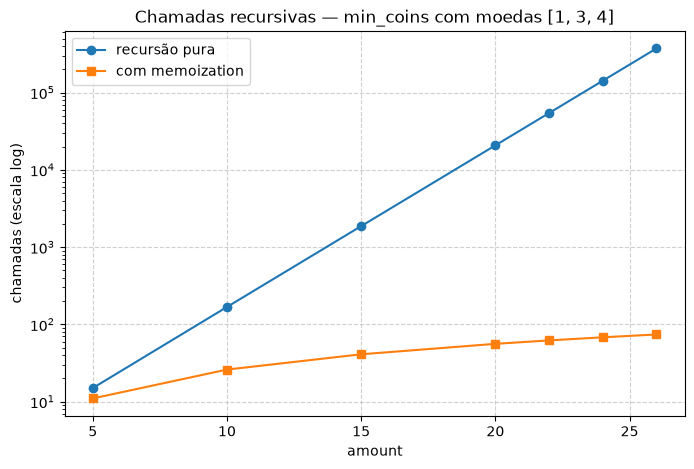

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(dp["amount"], dp["chamadas_puro"], marker="o", label="recursão pura")
plt.plot(dp["amount"], dp["chamadas_memo"], marker="s", label="com memoization")
plt.yscale("log")
plt.title("Chamadas recursivas — min_coins com moedas [1, 3, 4]")
plt.xlabel("amount")
plt.ylabel("chamadas (escala log)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

Em escala log, a pura vira uma reta subindo (exponencial) e a memoizada fica praticamente no chão.

## 4. A chave do memo

A chave é só o `amount`: a resposta depende apenas de quanto falta formar, e as moedas não mudam durante a execução. Para mostrar o que acontece com uma chave maior que o necessário, comparo com a chave `(amount, profundidade)`:

In [7]:
def min_coins_chave_grande(amount, coins, profundidade, cont, memo):
    cont.chamadas += 1
    chave = (amount, profundidade)       # informação a mais na chave
    if chave in memo:
        return memo.get(chave)
    if amount == 0:
        resultado = 0
    else:
        resultado = INFINITO
        for c in coins:
            if c <= amount:
                resultado = min(resultado,
                                min_coins_chave_grande(amount - c, coins, profundidade + 1, cont, memo) + 1)
    memo.put(chave, resultado)
    return resultado


linhas = []
for amount in [10, 20, 30, 40]:
    c_minima, m_minima = Contador(), HashTableChained()
    min_coins_memo(amount, moedas, c_minima, m_minima)
    c_grande, m_grande = Contador(), HashTableChained()
    min_coins_chave_grande(amount, moedas, 0, c_grande, m_grande)
    linhas.append({
        "amount": amount,
        "chave = amount: chamadas": c_minima.chamadas, "estados": len(m_minima),
        "chave = (amount, profundidade): chamadas": c_grande.chamadas, "estados ": len(m_grande),
    })
pd.DataFrame(linhas)

,amount,chave = amount: chamadas,estados,"chave = (amount, profundidade): chamadas",estados
0,10,26,11,68,39
1,20,56,21,346,152
2,30,86,31,848,339
3,40,116,41,1576,602


Com a chave maior o memo guarda muito mais estados e faz muito mais chamadas, porque "faltam 5" com 2 moedas e "faltam 5" com 3 moedas viram estados diferentes, apesar de terem a mesma resposta. O `amount` é a menor chave que ainda define a resposta.

## 5. A árvore de subproblemas

Numa execução memoizada, cada nó é um estado (o amount) e os filhos são as transições (tirar uma moeda). Um estado que já estava no memo aparece como folha marcada `(memo)`: é ali que a recursão foi podada.

In [8]:
class NoSubproblema:
    def __init__(self, estado):
        self.estado = estado
        self.filhos = []
        self.do_memo = False


def arvore_de_subproblemas(amount, coins):
    memo = HashTableChained()

    def resolver(a):
        no = NoSubproblema(a)
        if a in memo:
            no.do_memo = True
            return memo.get(a), no
        melhor = 0 if a == 0 else INFINITO
        for c in coins:
            if c <= a:
                r, filho = resolver(a - c)
                no.filhos.append(filho)
                melhor = min(melhor, r + 1)
        memo.put(a, melhor)
        return melhor, no

    return resolver(amount)


def imprimir(no, nivel=0):
    marca = "  (memo)" if no.do_memo else ""
    print("    " * nivel + f"faltam {no.estado}{marca}")
    for filho in no.filhos:
        imprimir(filho, nivel + 1)


resposta, raiz = arvore_de_subproblemas(6, [1, 3, 4])
print(f"min_coins(6, [1, 3, 4]) = {resposta}\n")
imprimir(raiz)

min_coins(6, [1, 3, 4]) = 2

faltam 6
    faltam 5
        faltam 4
            faltam 3
                faltam 2
                    faltam 1
                        faltam 0
                faltam 0  (memo)
            faltam 1  (memo)
            faltam 0  (memo)
        faltam 2  (memo)
        faltam 1  (memo)
    faltam 3  (memo)
    faltam 2  (memo)


O primeiro ramo resolve os estados pequenos, e os outros ramos que chegam neles param na hora.

### Busca por um estado na árvore

A árvore não é ordenada pelo estado, então a busca percorre os nós (em profundidade, com uma pilha).

In [9]:
def buscar_estado(raiz, estado):
    visitados = 0
    pilha = [raiz]
    while pilha:
        no = pilha.pop()
        visitados += 1
        if no.estado == estado and not no.do_memo:
            return no, visitados
        pilha.extend(reversed(no.filhos))    # mantém a ordem da esquerda para a direita
    return None, visitados


def contar_nos(raiz):
    return 1 + sum(contar_nos(f) for f in raiz.filhos)


_, raiz = arvore_de_subproblemas(30, [1, 3, 4])
total = contar_nos(raiz)
print(f"árvore de min_coins(30): {total} nós\n")
for estado in [30, 15, 2, 0, 99]:
    no, visitados = buscar_estado(raiz, estado)
    situacao = f"achado, com {len(no.filhos)} filho(s)" if no else "não existe"
    print(f"  estado {estado:>2}: {situacao:<24} — {visitados:>3} de {total} nós visitados")

árvore de min_coins(30): 86 nós

  estado 30: achado, com 3 filho(s)   —   1 de 86 nós visitados
  estado 15: achado, com 3 filho(s)   —  16 de 86 nós visitados
  estado  2: achado, com 1 filho(s)   —  29 de 86 nós visitados
  estado  0: achado, com 0 filho(s)   —  31 de 86 nós visitados
  estado 99: não existe               —  86 de 86 nós visitados


A busca é O(N), com N nós (O(amount·k) com memoization). A raiz sai na primeira visita, os estados pequenos ficam no fundo do primeiro ramo e custam mais, e um estado que não existe obriga a visitar todos os nós. Para buscar estados muitas vezes, seria melhor guardar os nós numa hashtable indexada pelo estado (O(1) em média).

## 6. O limite da recursão e a versão com tabela

A memoizada ainda é recursiva: com amount = 5000 e moeda 1 ela passa do limite de recursão. A versão bottom-up (como o LCS da aula) preenche uma tabela de 0 até amount, sem recursão.

In [10]:
def min_coins_tabela(amount, coins):
    validar(amount, coins)
    tabela = [0] + [INFINITO] * amount       # tabela[a] = menor número de moedas para formar a
    for a in range(1, amount + 1):
        for c in coins:
            if c <= a and tabela[a - c] + 1 < tabela[a]:
                tabela[a] = tabela[a - c] + 1
    return -1 if tabela[amount] == INFINITO else tabela[amount]


# as três versões concordam
for amount in range(0, 40):
    assert min_coins_tabela(amount, moedas) == min_coins_memoizado(amount, moedas)[0]
for amount in range(0, 20):
    assert min_coins_tabela(amount, moedas) == min_coins(amount, moedas)[0]

grande = 5000
print(f"limite de recursão: {sys.getrecursionlimit()}")
try:
    min_coins_memoizado(grande, moedas)
except RecursionError:
    print(f"memoizada com amount = {grande}: RecursionError")
print(f"tabela com amount = {grande}: {min_coins_tabela(grande, moedas)} moedas (O(amount · k), sem recursão)")

limite de recursão: 1000
memoizada com amount = 5000: RecursionError
tabela com amount = 5000: 1250 moedas (O(amount · k), sem recursão)


## 7. Casos de borda

In [11]:
assert min_coins(0, [5])[0] == 0                   # nada a formar
assert min_coins(3, [5])[0] == -1                  # moeda maior que o valor
assert min_coins_memoizado(7, [2, 4])[0] == -1     # impossível
assert min_coins_tabela(7, [2, 4]) == -1
assert min_coins(10, [10])[0] == 1                 # moeda única que cabe exato
assert min_coins_memoizado(11, [5, 1, 5])[0] == 3  # moeda repetida na lista não atrapalha

for amount, coins in [(-1, [1]), (5, []), (5, [0, 1]), (5, [-2])]:
    try:
        min_coins(amount, coins)
        raise AssertionError(f"deveria recusar amount={amount}, coins={coins}")
    except ValueError as erro:
        print(f"min_coins({amount}, {coins}) → {erro}")

print("\ntodos os casos de borda passaram")

min_coins(-1, [1]) → amount não pode ser negativo: -1
min_coins(5, []) → as moedas precisam ser positivas: []
min_coins(5, [0, 1]) → as moedas precisam ser positivas: [0, 1]
min_coins(5, [-2]) → as moedas precisam ser positivas: [-2]

todos os casos de borda passaram


## Resumo

- recursiva pura: exponencial (cerca de 1,618^amount com as moedas [1, 3, 4])
- memoizada: O(amount·k), mas limitada pela profundidade de recursão
- tabela: O(amount·k), sem limite de recursão

A memoization troca memória (amount + 1 resultados guardados) por tempo.